In [9]:
from pathlib import Path
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd

In [10]:
# Filter results with mask before calculating statistics
# Bug in prediction pipeline cuts bottom of heatmaps

In [28]:
VOLUME_LOSS_PATH = Path(f"../preprocess/rawdata/processed/volume-loss/volume-loss.csv")
plt.rcParams.update({'font.size': 18})

def get_mask_path(data_type):
    return Path(f"../data/{data_type}/mask")

def get_target_path(data_type):
    return Path(f"../data/{data_type}/after/height")

def get_save_path(model, data_type):
    return Path(f"predictions/{model}/{data_type}")

def get_image(image_path, mask_path, file):
    image = np.load(image_path / file)
    mask = np.load(mask_path / file)
    image[mask] = 0.0
    return image

def save_side_by_side(model, data_type):

    save_path = get_save_path(model, data_type)
    ground_truth_path = get_target_path(data_type)
    mask_path = get_mask_path(data_type)

    numpy_save_path = save_path / "numpy"
    side_by_side_save_path = save_path / "side-by-side"
    side_by_side_save_path.mkdir(parents=True, exist_ok=True)

    files = os.listdir(numpy_save_path)

    for f in files:
        target = get_image(ground_truth_path, mask_path, f)
        prediction = get_image(numpy_save_path, mask_path, f)

        max_val = 0.0
        min_val = min(target.min(), prediction.min())

        fig = plt.figure(figsize=(10, 4))

        # 1 row, 3 columns: 2 for images, 1 thin column for colorbar
        gs = GridSpec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.1)

        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        cax = fig.add_subplot(gs[0, 2])  # dedicated colorbar axis

        im1 = ax1.imshow(target, vmin=min_val, vmax=max_val, cmap="plasma_r")
        ax1.set_title("Ground Truth")
        im2 = ax2.imshow(prediction, vmin=min_val, vmax=max_val, cmap="plasma_r")
        ax2.set_title("Prediction")
        fig.colorbar(im2, cax=cax)
        plt.savefig(side_by_side_save_path / f.replace("npy", "png"), bbox_inches="tight")

def calc_loss(image):
    """Sum all negative elements"""
    return -(image[image < 0.0].sum())

def calc_max_loss(image):
    return -(image[image < 0.0].min())

def get_loss_df(image_path, mask_path):
    """Create a pandas df from the loss of all height profiles"""
    file_list = os.listdir(image_path)
    loss = []
    max_loss = []

    for file in file_list:
        image = get_image(image_path, mask_path, file)
        loss.append(calc_loss(image))
        max_loss.append(calc_max_loss(image))

    ident = [file.replace(".npy", "") for file in file_list]
    return pd.DataFrame({"id": ident, "loss": loss, "max_loss": max_loss})

def analyse_model(model, data_types):
    results, inhibitor = create_result_df(model, data_types)
    analyse_samples(results, data_types, title="Results per sample")
    analyse_samples(inhibitor, data_types, title="Results per inhibitor")

def load_inibitor_map():
    result = pd.read_csv(VOLUME_LOSS_PATH, index_col=0)
    result["inhibitor"] = result.id.str[:-2]
    return result

def create_result_df(model, data_types):

    # Read inhibitor map
    results = load_inibitor_map()
    # Create inhibitor id
    all_losses = []
    for dtype in data_types:
        numpy_save_path = get_save_path(model, dtype) / "numpy"
        ground_truth_path = get_target_path(dtype)
        mask_path = get_mask_path(dtype)

        # Calculate the corrision for target and prediciton and join the dataframes
        losses = get_loss_df(ground_truth_path, mask_path).join(get_loss_df(numpy_save_path, mask_path).set_index("id"), on="id", how="inner", lsuffix="_target", rsuffix="_predict")
        # losses = get_loss_df(numpy_save_path, mask_path).join(get_loss_df(numpy_save_path, mask_path).set_index("id"), on="id", how="inner", lsuffix="_target", rsuffix="_predict")

        # Add data type indentifier
        losses["type"] = dtype
        all_losses.append(losses)

    # Concat the two datatype dataframes
    losses = pd.concat(all_losses)

    # Join to the inhibitor map
    results = results.join(losses.set_index("id"), on="id", how="inner").sort_values("id")
    # Calculate loss per inhibitor
    inhibitor = results[["inhibitor", "type", "loss_target", "loss_predict"]].groupby(["inhibitor", "type"]).agg("mean").reset_index()
    return results, inhibitor

def rel_pred_loss(df):
    return df.loss_predict / df.loss_target.max()

def rel_target_loss(df):
    return df.loss_target / df.loss_target.max()

def difference(df):
    return (df.loss_target - df.loss_predict)/(np.max((df.loss_target - df.loss_predict)) - np.min((df.loss_target - df.loss_predict)))

def deviation_percent(df):
    return 100 * (df.loss_target - df.loss_predict) / df.loss_target

def analyse_samples(input_df, data_types, title=None):
    fig, ax = plt.subplots(3, 2, figsize=(16, 18), constrained_layout=True)
    fig.suptitle(title)

    for dtype in data_types:
        df = input_df[input_df.type == dtype]
        x = rel_target_loss(df)
        y = rel_pred_loss(df)
        ax[0][0].scatter(x, y, label=dtype)
    ax[0][0].plot(np.arange(0.0, 1.0, 0.01), np.arange(0.0, 1.0, 0.01), color="r")
    ax[0][0].set_xlabel("Corrosion Target / a.u.")
    ax[0][0].set_ylabel("Corrosion Prediction / a.u.")
    ax[0][0].grid()
    ax[0][0].legend()

    for dtype in data_types:
        df = input_df[input_df.type == dtype]
        x = rel_target_loss(df)
        y = difference(df)
        ax[0][1].scatter(x, y, label=dtype)
    ax[0][1].set_xlabel("Corrosion Target / a.u.")
    ax[0][1].set_ylabel("Difference (Target - Predicted) / a.u.")
    ax[0][1].grid()
    ax[0][1].legend()


    for dtype in data_types:
        df = input_df[input_df.type == dtype]
        x = rel_target_loss(df)
        y = deviation_percent(df)
        ax[1][0].scatter(x, y, label=dtype)
    ax[1][0].set_xlabel("Corrosion Target / a.u.")
    ax[1][0].set_ylabel("Deviation %")
    ax[1][0].grid()

    for dtype in data_types:
        df = input_df[input_df.type == dtype]
        x = rel_target_loss(df)
        y = deviation_percent(df)
        ax[1][1].scatter(x, y, label=dtype)
    ax[1][1].set_xlabel("Corrosion Target / a.u.")
    ax[1][1].set_ylabel("Deviation %")
    ax[1][1].set_yticks(np.arange(-100, 110, 10))
    ax[1][1].set_ylim(-100, 100)
    ax[1][1].grid()

    res_list = []
    for dtype in data_types:
        df = input_df[input_df.type == dtype]
        y = deviation_percent(df)
        res_list.append(y)
    ax[2][0].boxplot(res_list)
    ax[2][0].set_xticklabels(data_types)
    ax[2][0].set_ylabel("Deviation %")
    ax[2][0].grid()

    res_list = []
    for dtype in data_types:
        df = input_df[input_df.type == dtype]
        y = deviation_percent(df)
        res_list.append(y)
    ax[2][1].boxplot(res_list)
    ax[2][1].set_xticklabels(data_types)
    ax[2][1].set_yticks(np.arange(-100, 110, 10))
    ax[2][1].set_ylim(-100, 100)
    ax[2][1].set_ylabel("Deviation %")
    ax[2][1].grid()
    plt.show()

In [29]:
model = "model-d2rltbw6-best"
data_type = "test"

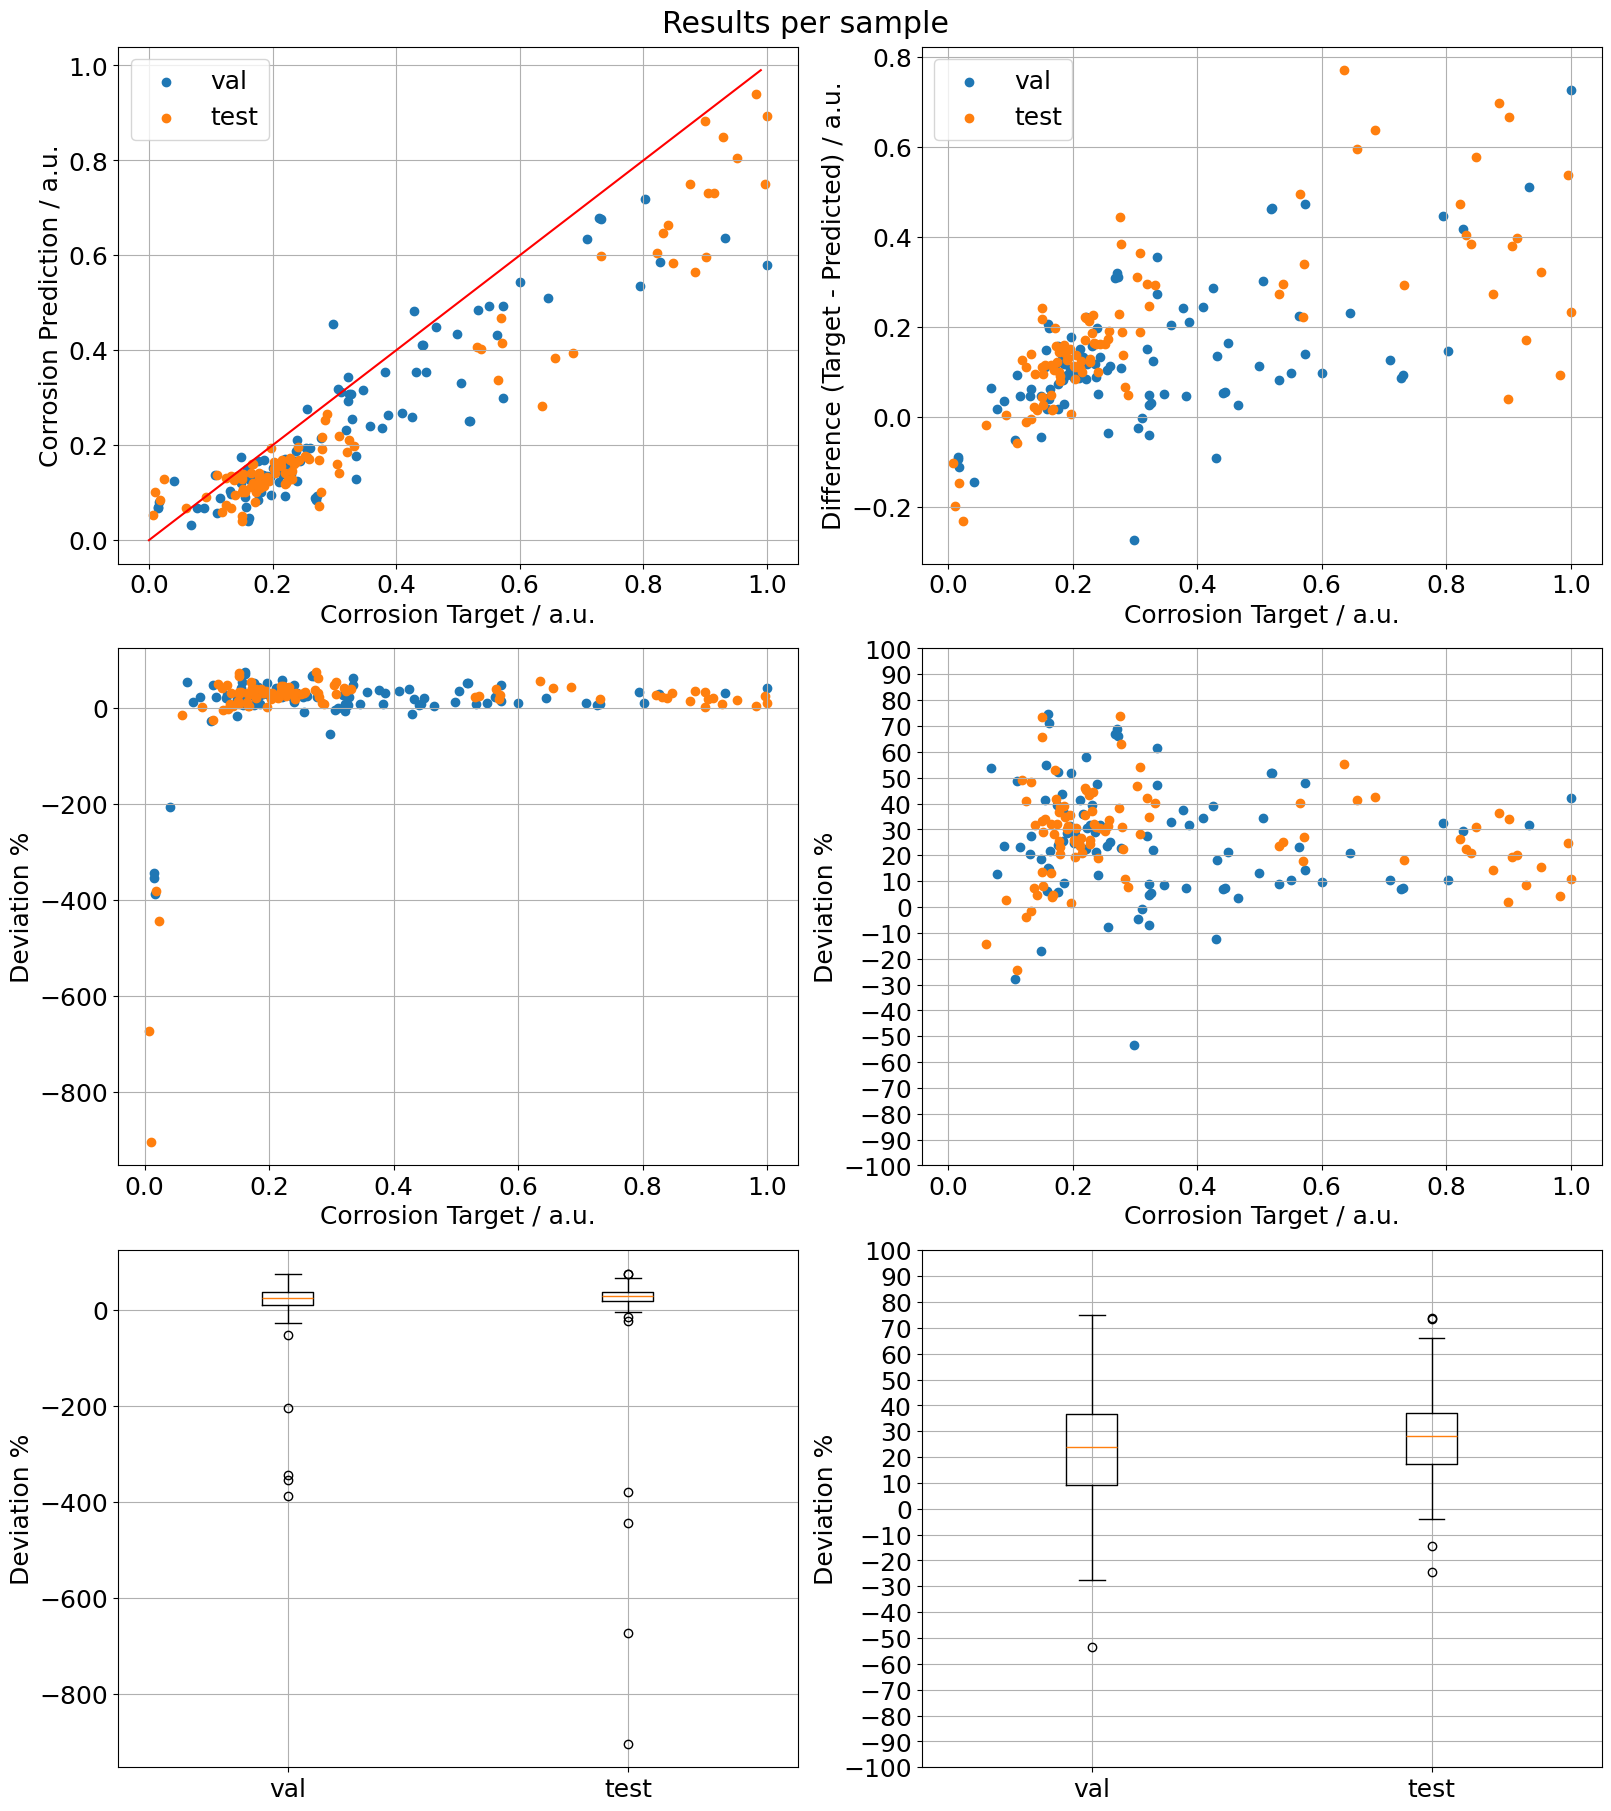

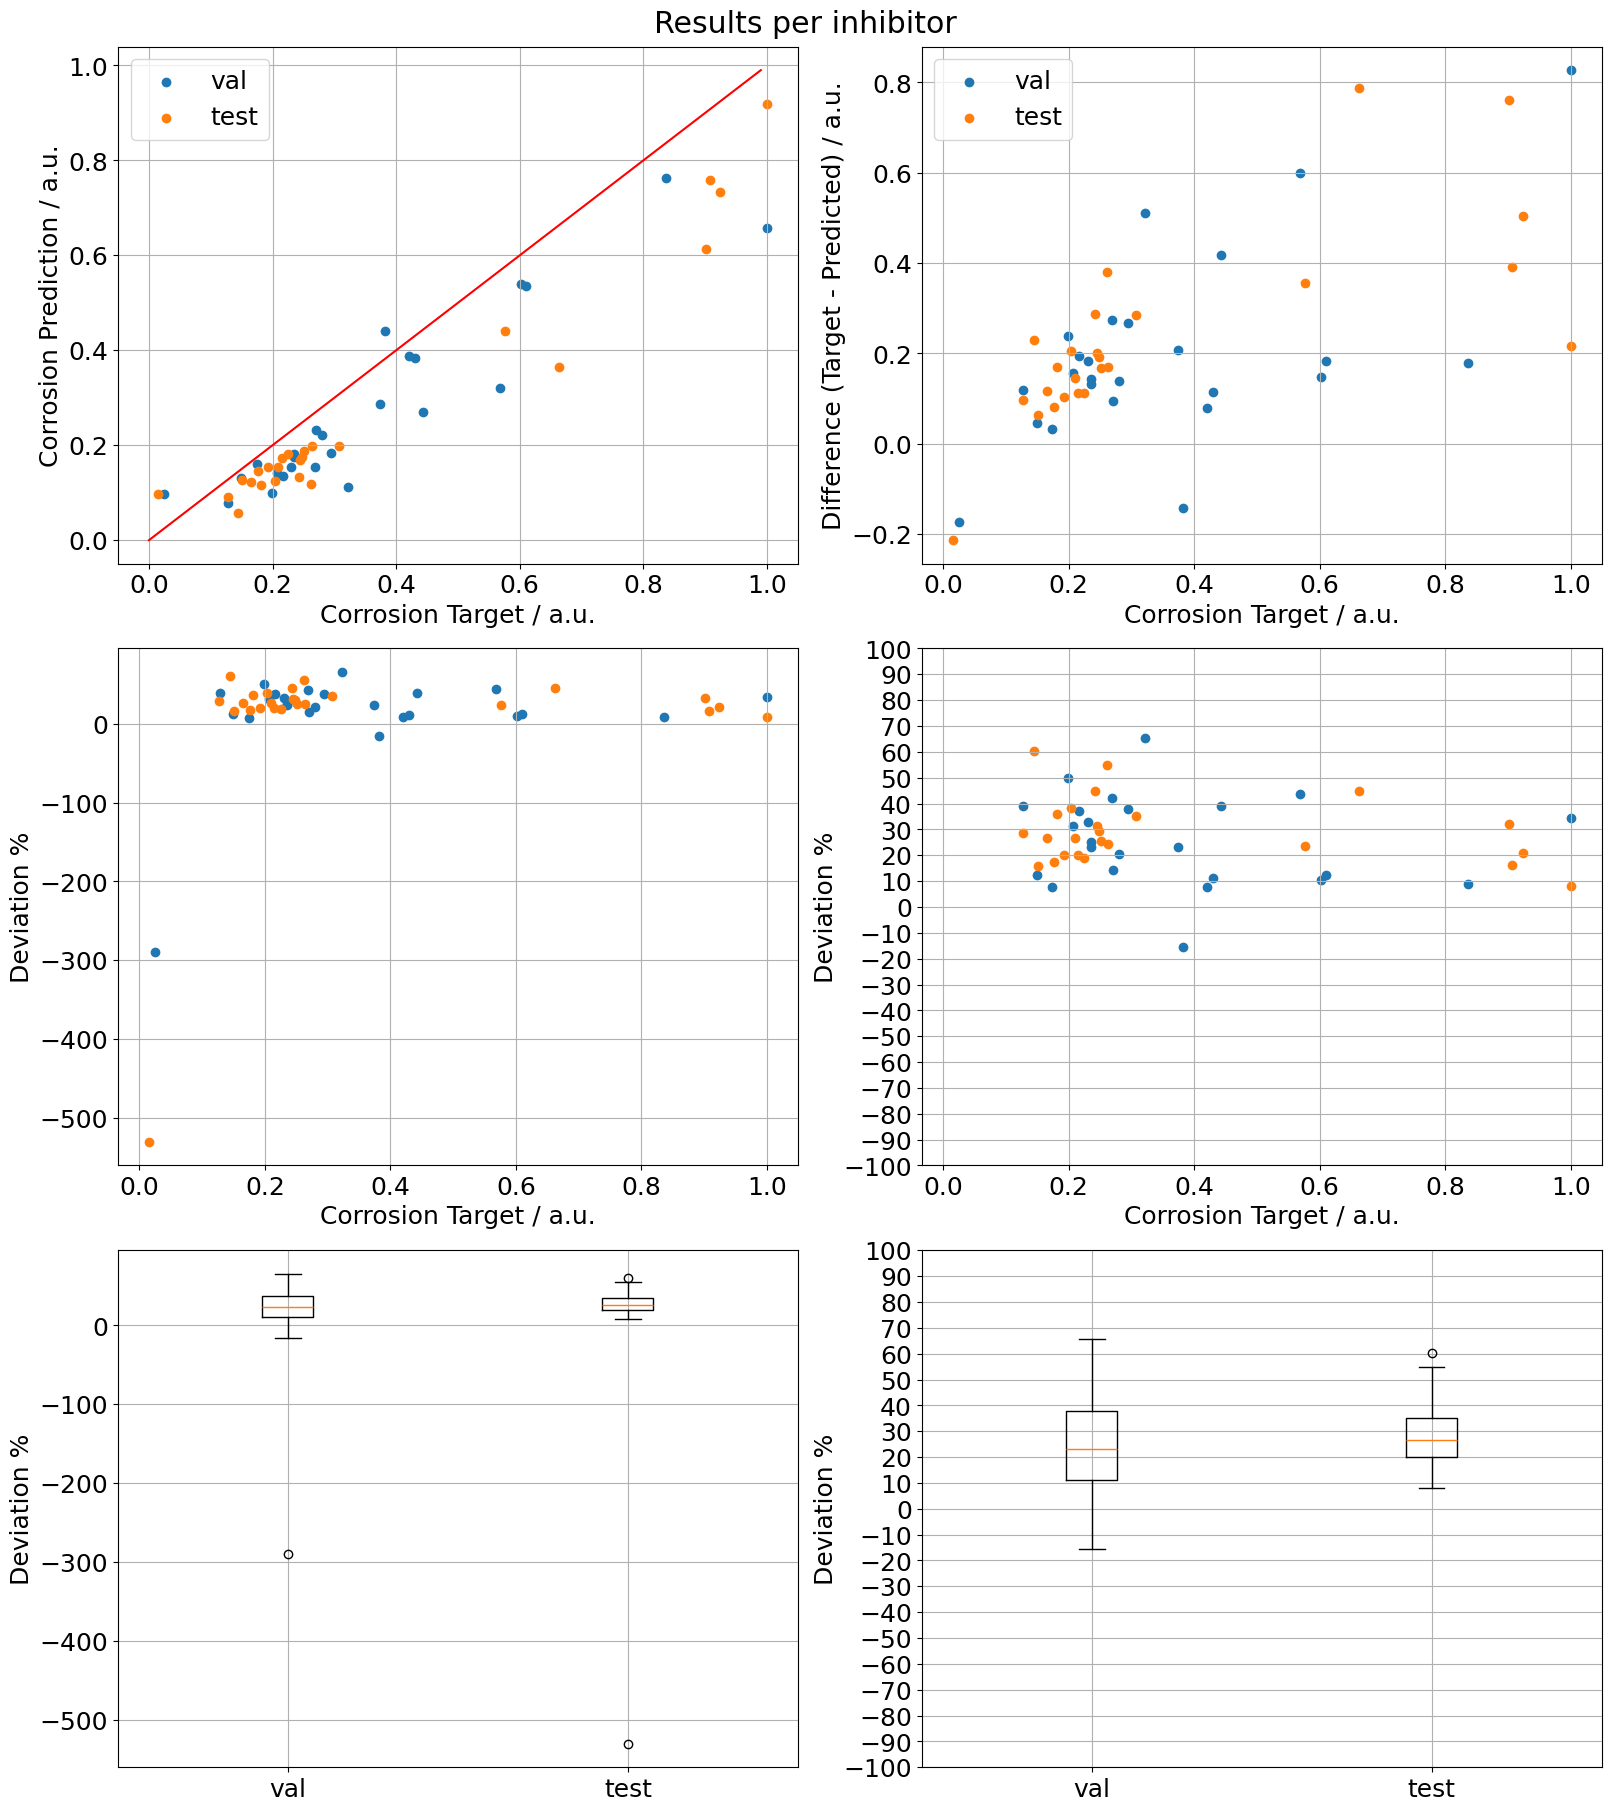

In [30]:
analyse_model(model, ["val", "test"])

## Side by side Test data

In [ ]:
save_side_by_side(model, "test")

## Side by side Validation data

In [ ]:
save_side_by_side(model, "val")